In [6]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns  

data = pd.read_csv("train.csv")

data.head()

# data.info()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [44]:
#ageMean = data['Age'].mean()
#print("Age Mean: ",ageMean)

#flightDistanceMedian = data['Flight Distance'].median()
#print("Flight Distance Mean: ",flightDistanceMedian)

#onlineBoardingMean = data['Online boarding'].mean()
#print("Online Boarding Mean: ",onlineBoardingMean)

In [5]:
# 2. İstatistiksel Özet

# select only meaningful columns for calculation
selectedColumns = {
    'Age': {
        'Mean': round(data['Age'].mean()),
        'Median': round(data['Age'].median()),
        'Std': round(data['Age'].std()),
        'Min': int(data['Age'].min()),
        'Max': int(data['Age'].max())
    },
    'Flight Distance': {
        'Mean': round(data['Flight Distance'].mean(), -1),
        'Median': round(data['Flight Distance'].median(), -1),
        'Std': round(data['Flight Distance'].std(), -1),
        'Min': int(data['Flight Distance'].min()),
        'Max': int(data['Flight Distance'].max())
    },
    'Departure Delay in Minutes': {
        'Mean': round(data['Departure Delay in Minutes'].mean()),
        'Median': round(data['Departure Delay in Minutes'].median()),
        'Std': round(data['Departure Delay in Minutes'].std()),
        'Min': int(data['Departure Delay in Minutes'].min()),
        'Max': int(data['Departure Delay in Minutes'].max())
    },
    'Arrival Delay in Minutes': {
        'Mean': round(data['Arrival Delay in Minutes'].mean()),
        'Median': round(data['Arrival Delay in Minutes'].median()),
        'Std': round(data['Arrival Delay in Minutes'].std()),
        'Min': int(data['Arrival Delay in Minutes'].min()),
        'Max': int(data['Arrival Delay in Minutes'].max())
    },
    'Inflight wifi service': {
        'Mean': round(data['Inflight wifi service'].mean()),
        'Median': round(data['Inflight wifi service'].median()),
        'Std': round(data['Inflight wifi service'].std()),
        'Min': int(data['Inflight wifi service'].min()),
        'Max': int(data['Inflight wifi service'].max())
    },
    'Seat comfort': {
        'Mean': round(data['Seat comfort'].mean()),
        'Median': round(data['Seat comfort'].median()),
        'Std': round(data['Seat comfort'].std()),
        'Min': int(data['Seat comfort'].min()),
        'Max': int(data['Seat comfort'].max())
    },
    'Food and drink': {
        'Mean': round(data['Food and drink'].mean()),
        'Median': round(data['Food and drink'].median()),
        'Std': round(data['Food and drink'].std()),
        'Min': int(data['Food and drink'].min()),
        'Max': int(data['Food and drink'].max())
    }
}

# convert pandas DatFrame
rounded_df = pd.DataFrame(selectedColumns).T
rounded_df.columns = ['Mean', 'Median', 'Standard Deviation', 'Minimum', 'Maximum']
display(rounded_df)




,Mean,Median,Standard Deviation,Minimum,Maximum
Age,39.0,40.0,15.0,7.0,85.0
Flight Distance,1190.0,840.0,1000.0,31.0,4983.0
Departure Delay in Minutes,15.0,0.0,38.0,0.0,1592.0
Arrival Delay in Minutes,15.0,0.0,39.0,0.0,1584.0
Inflight wifi service,3.0,3.0,1.0,0.0,5.0
Seat comfort,3.0,4.0,1.0,0.0,5.0
Food and drink,3.0,3.0,1.0,0.0,5.0


In [65]:
# 3. Eksik Değer Analizi

# calculate missing value count
missingValueCount = data.isnull().sum()

# calculate missing value percentage
missingValuePercent = (missingValueCount / len(data)) * 100

# cretae a DataFrame about missing values
missingValues = pd.DataFrame({
    'Missing Values': missingValueCount,
    'Missing Percentage': missingValuePercent.round(2)
})

# select only missing values
missingValues = missingValues[missingValues['Missing Values'] > 0]

print("Missing Values in the dataset:")
display(missingValues)


### In our dataset, missing values exist only in the “Arrival Delay in Minutes” column,
### with a very low missing rate of 0.3% (310 records).
### The best approach in this case is to fill the missing values with the median.

Missing Values in the dataset:


,Missing Values,Missing Percentage
Arrival Delay in Minutes,310,0.3


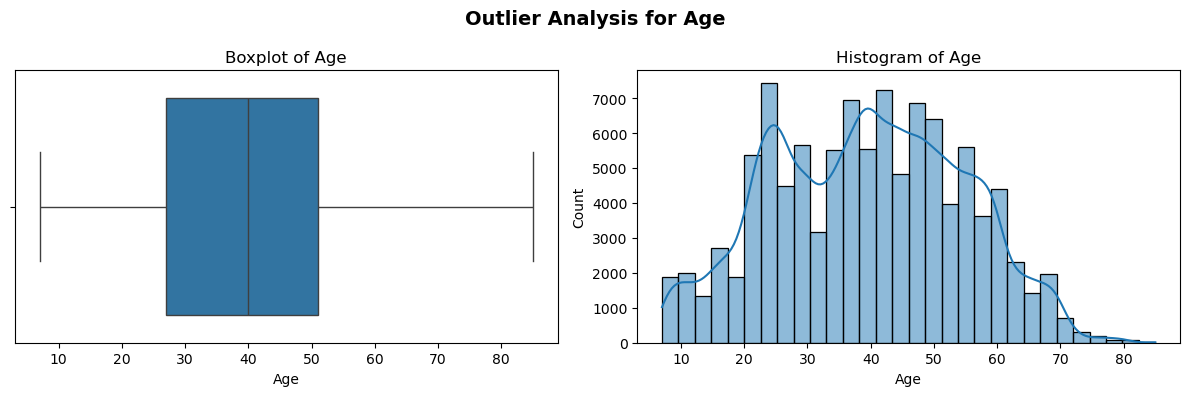

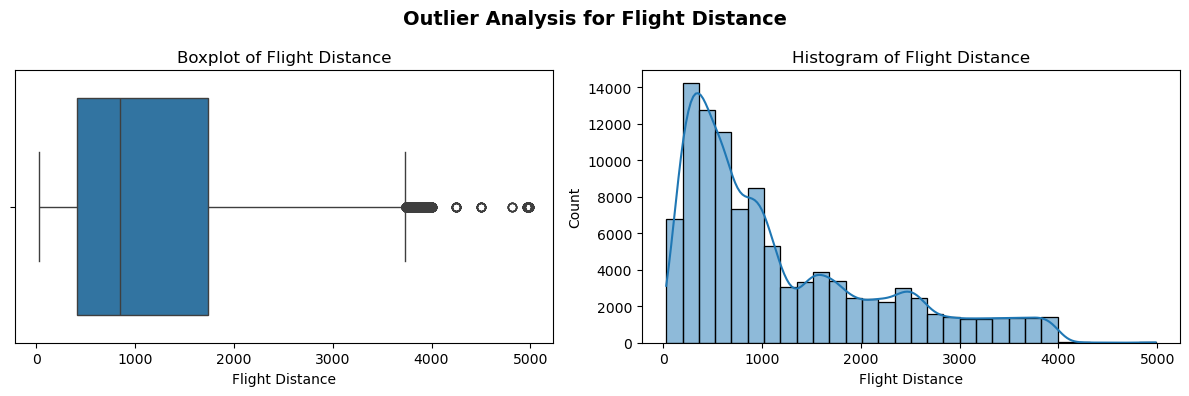

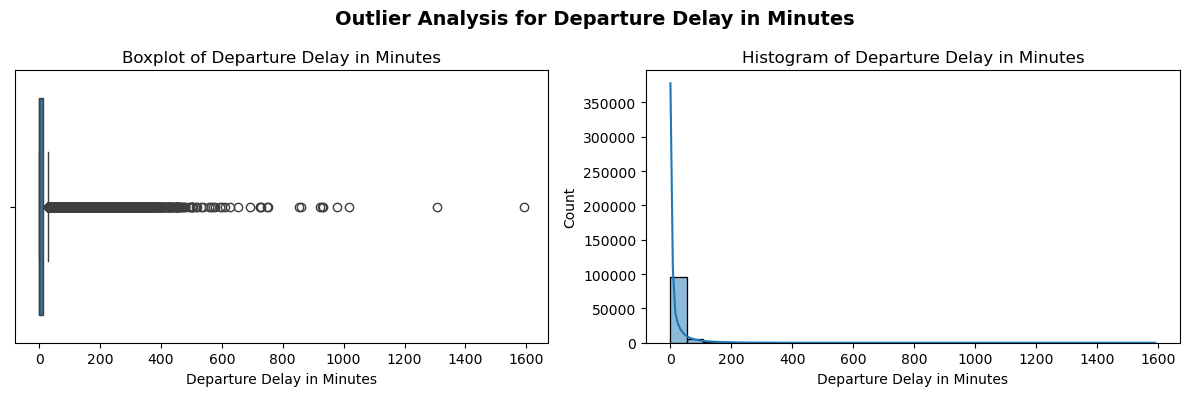

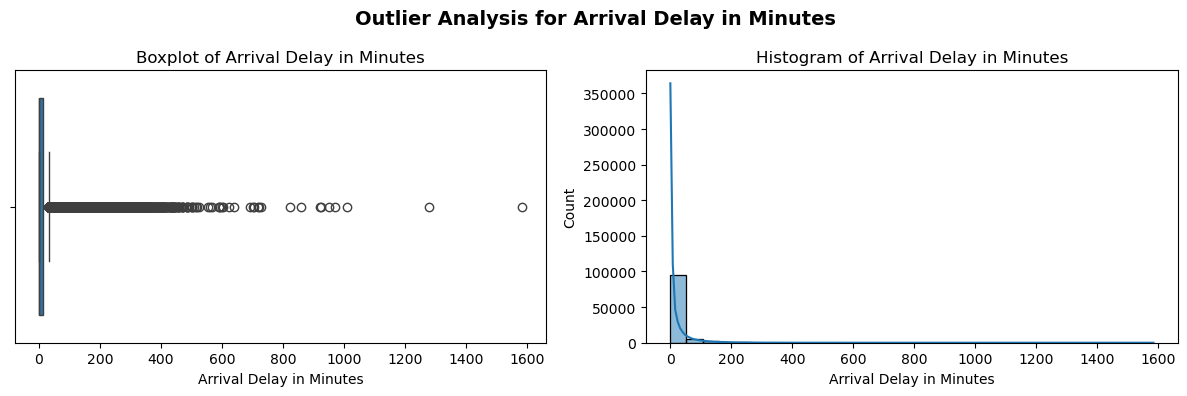

,Column Name,Total Values,Outlier Value Count,Outlier Percentage
0,Age,103904.0,0.0,0.00
1,Flight Distance,103904.0,2291.0,2.20
2,Departure Delay in Minutes,103904.0,14529.0,13.98
3,Arrival Delay in Minutes,103904.0,13954.0,13.43


In [10]:
# 4. Aykırı Değer (Outlier) Analizi

# Calculation parts

# select just important columns for calculations
columns = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

temp = {} # declare temp 

# calculate IQR value for each column
for col in columns:

    Q1 = data[col].quantile(0.25) # set Q1 to %25
    Q3 = data[col].quantile(0.75) # set Q2 to %75
    IQR = Q3 - Q1 # calculate IQR value
    lower = Q1 - 1.5 * IQR # calculate lower
    upper = Q3 + 1.5 * IQR # calculate upper

    # calculate outlier values
    outlier = data[(data[col] < lower) | (data[col] > upper)]

    # setting table
    temp[col] = {
        'Total Values': len(data[col]),
        'Outlier Value Count': len(outlier),
        'Outlier %': round(len(outlier) / len(data[col]) * 100, 2)
    }

# Visualization part 
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')

    # Histogram
    plt.subplot(1, 2, 2)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')

    plt.suptitle(f'Outlier Analysis for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Sonuçları DataFrame olarak göster
outlier_df = pd.DataFrame(temp).T
outlier_df.reset_index(inplace=True)
outlier_df.columns = ['Column Name', 'Total Values', 'Outlier Value Count', 'Outlier Percentage']
outlier_df


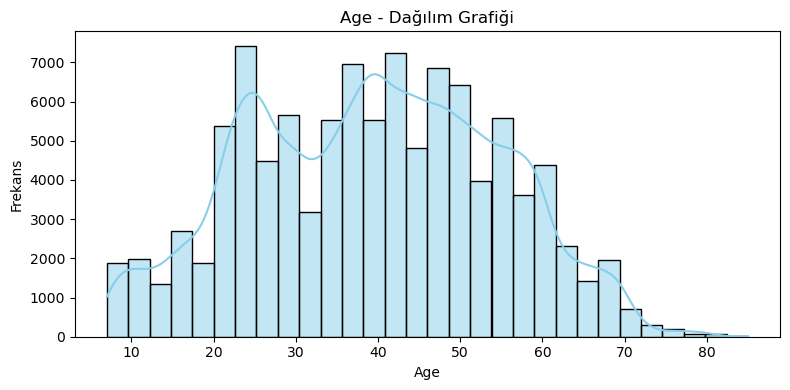

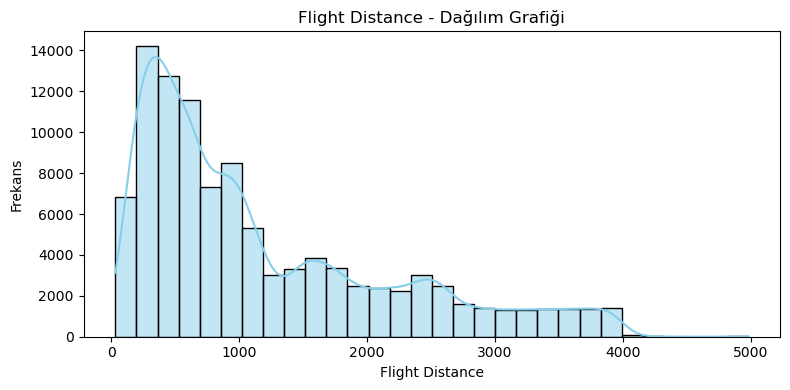

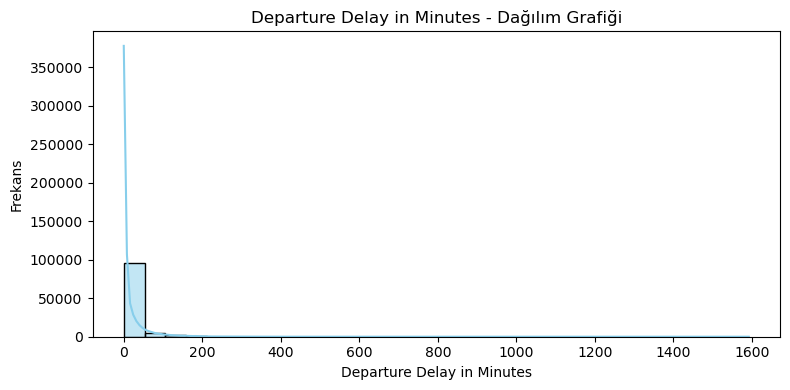

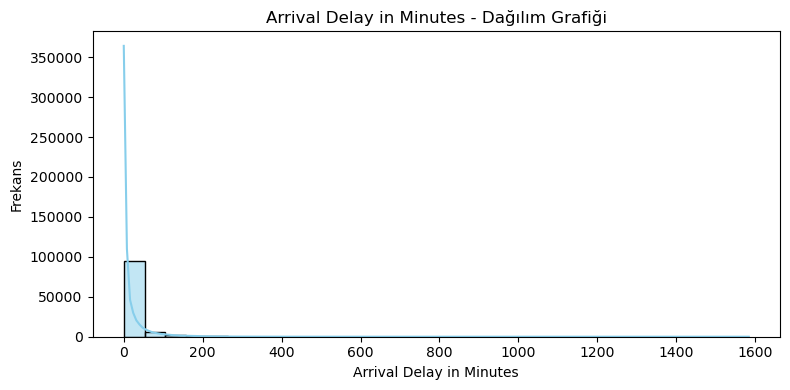

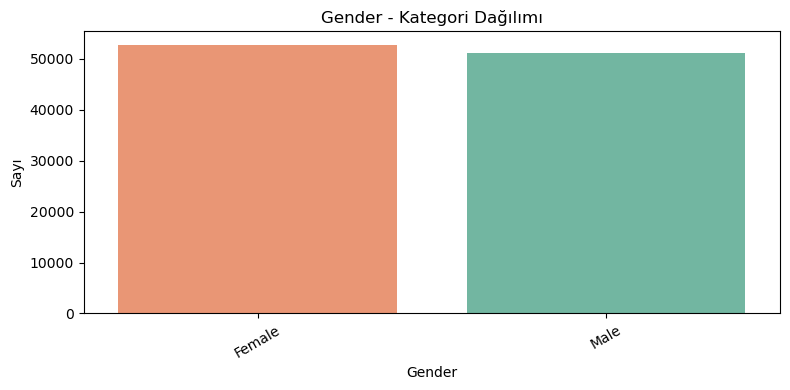

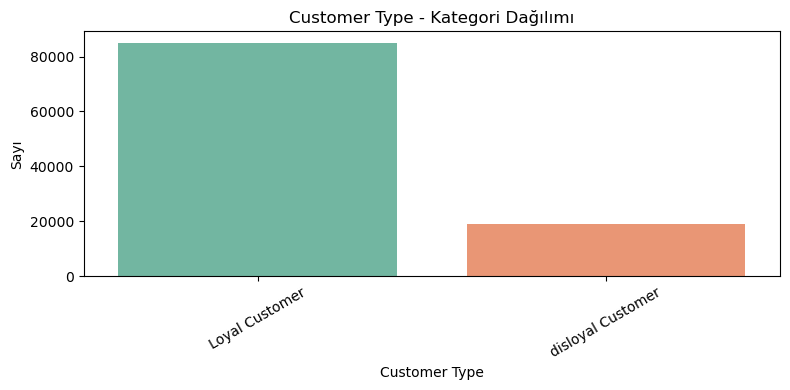

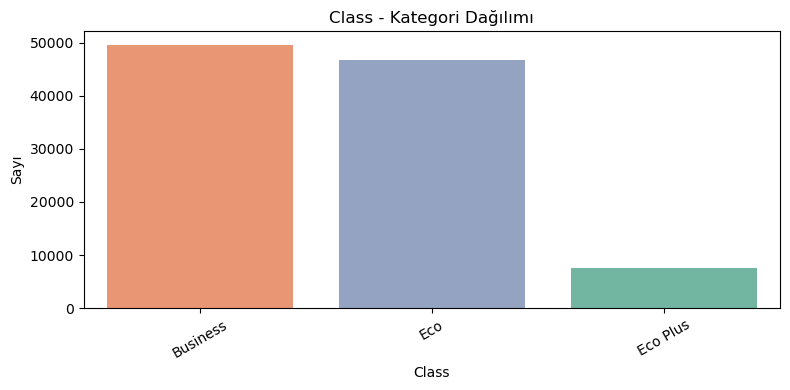

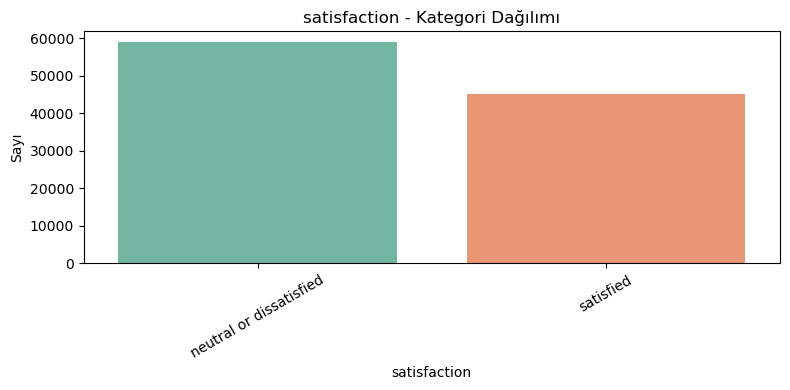

In [15]:
# 5. Görselleştirme

# select important numerical columns for calculations 
columns_numerical = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in columns_numerical:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(f"{col} - Dağılım Grafiği")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.tight_layout()
    plt.show()


# select important categoric columns for calculations 
categorical_cols = ['Gender', 'Customer Type', 'Class', 'satisfaction']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, hue=col, order=data[col].value_counts().index, palette="Set2", legend=False)
    plt.title(f"{col} - Kategori Dağılımı")
    plt.xlabel(col)
    plt.ylabel("Sayı")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()